In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pymatgen.core.composition as comp
import importlib

import mlcpquicker
import reference3 as ref3

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, HistGradientBoostingClassifier,HistGradientBoostingRegressor,GradientBoostingClassifier,GradientBoostingRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix,mean_squared_error,mean_absolute_error,ConfusionMatrixDisplay, r2_score, f1_score,roc_curve, roc_auc_score



In [11]:
#reload these home-made packages in case any changes are made
importlib.reload(mlcpquicker)
importlib.reload(ref3)


<module 'reference3' from '/Users/aboth/Desktop/gordon/mlcpproject/mlcp code/reference3.py'>

In [12]:
#pandas view settings
pd.set_option('display.max_rows',None)
pd.set_option('display.min_rows',50)
pd.set_option('display.max_columns',None)

In [13]:
formulas=['Ag8SnSe6', 'Cu12Sb4S13', 'MgAgSb', 'SnSe', 'TiS2', 'VFeSb',
       'LiCoO2', 'GeTe', 'CoGeTe', 'CuFeS2', 'Co9S8', 'CoS2', 'CoSi',
       'Tl2GeTe3', 'BaBiTe3', 'Tl4SnTe3', 'Sb2Si2Te6', 'Bi2Te3',
       'YbCd2Sb2', 'YbSi2', 'Rb2Bi8Se13', 'AgBiSe2', 'BaTmCo4O7',
       'BaLuCo4O7', 'BaDyCo4O7', 'CsPr2Ag3Te5', 'CsSm2Ag3Te5', 'TlCr5Se8',
       'Ca14MgBi11', 'BiCuSeO', 'Ca11Sb10', 'As2Te3', 'Bi2Si2Te6',
       'Ca5In2Sb6', 'Cr2Ge2Te6', 'Ca3AlSb3', 'Yb14MnSb11', 'Ca5Ga2Sb6',
       'Tl4PbTe3', 'Sr14MgBi11', 'Mg3Sb2', 'EuCd2Sb2', 'SnS',
       'Eu14MgBi11', 'Yb14MgBi11', 'Cu3SbS4', 'BaZn2As2', 'PbTe',
       'Cu2SnSe3', 'BaGd2NiO5', 'Cu2SnS3', 'Cu3ErTe3', 'EuZn2Sb2',
       'Cu2CdSnSe4', 'GeSe', 'Nd3Te4', 'Cu3SbSe4', 'ZrNiSn', 'Cu2ZnSnSe4',
       'CaTiO3', 'TiNiSn', 'Cu5Sn2Se7', 'Cu26V2Ge6S32', 'Cu5Sn2S7',
       'SnTe', 'CuGaTe2', 'Ca3Co2O6']

In [14]:
#loading data
mlcpdata = np.load('mlcpdata67.npy',allow_pickle='TRUE').item()

In [15]:
mlcpkeys=mlcpdata['SnS'].keys()

<function matplotlib.pyplot.show(close=None, block=None)>

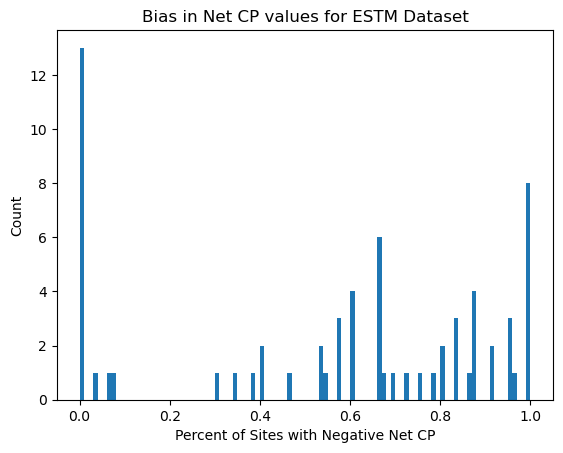

In [16]:
negpct=[np.mean([1 if j<0 else 0 for j in mlcpdata[i]['CP']]) for i in mlcpdata.keys()]
plt.hist(negpct,100);
plt.title('Bias in Net CP values for ESTM Dataset')
plt.xlabel('Percent of Sites with Negative Net CP')
plt.ylabel('Count')
plt.savefig('IMAGES/Bias in Net CP values ESTM Data.svg', bbox_inches='tight', dpi=1200)
plt.show

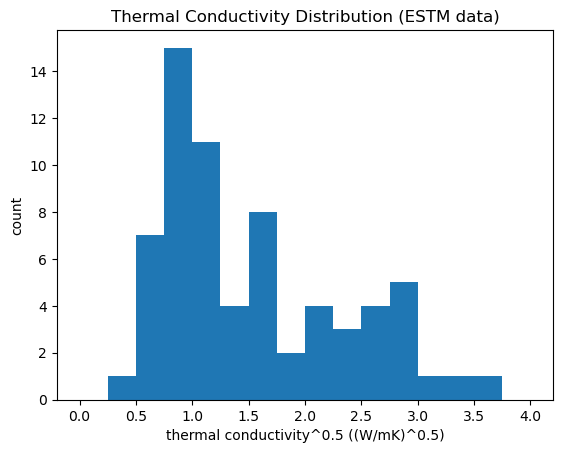

In [17]:
mlcpdatabasedata=pd.read_csv('mlcpdatabasedata.csv')
mlcpdatabasedata['rootkappa']=mlcpdatabasedata['thermal_conductivity(W/mK)']**0.5
plt.hist(mlcpdatabasedata['rootkappa'],np.linspace(0,4,17));
plt.title('Thermal Conductivity Distribution (ESTM data)')
plt.xlabel('thermal conductivity^0.5 ((W/mK)^0.5)')
plt.ylabel('count')
plt.savefig('IMAGES/Thermal Conductivity Distribution (ESTM data).png', bbox_inches='tight', dpi=1200)

In [18]:
#information carried for each entry

# result={}
# result['CIFname']=cif[:-4] #compound name (from cif)
# result['directory']=directory_name
# result['name']=structure.composition.reduced_formula #reduced formula
# result['elements']=stoich #the element identifier of each
# result['counts']=s_tot #cumulutaive total of each element, with some factor
# result['abc']=structure.lattice.abc #abc lattice lengths
# result['cell']=cell #cell matrix
# result['e_data']=e_data #the structure-wide data inputs
# result['totalCP']=float(data[-1][1][:-4]) #total CP (GPa)
# result['sites']=sitenames #atom at each site
# result['geo']=geo #coords of each atom
# result['CP']=cpvalues # predictions at l=0, the number we've been working with (GPa)
# result['Xs']=qps0 #l=0 contribution
# result['neighbors']=neighbors #each site's neighbors
# result['contacts']=[row[0:2] for row in unique] #unique contacts
# result['rfrpredictions']=predictions_rfr #for each in unique contacts
# result['coeffs']=coeffs #coefficient outputs
# result['allvnn']=allvnn #info on all voronoi cells
# result['bptable']=bptable #values here: first atom/coords, second, ml-cp, #points nearby, (half of) the volume of the contact taken up
# result['bptablekey']=bptableguide #indices of the first atom, and the number of the associated contact

In [19]:
forms={}
for i in range(len(formulas)):
    forms[i]=formulas[i]

In [20]:
database = pd.read_csv('mlcpdatabasedata.csv', index_col=0)

In [21]:
database.sort_values(by=['Formula'])

,index,Formula,temperature(K),seebeck_coefficient(μV/K),electrical_conductivity(S/m),thermal_conductivity(W/mK),power_factor(W/mK2),ZT,reference,net_MLCP,rattlercount,Xs,CP,mechanism,rattler,CIF
0,4,Ag8SnSe6,330,-543.0,99.0,0.21,0.00003,0.05,https://doi.org/10.1021/acsami.1c17548,-65.78,2 Ag,0.65,-274.0,maybe layers?,False,NaN
21,126,AgBiSe2,300,-526.0,6.0,0.53,0.00000,0.00,https://doi.org/10.1021/acs.inorgchem.9b00874,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31,342,As2Te3,298,119.0,185.0,0.85,0.00000,0.00,https://doi.org/10.1021/acs.inorgchem.6b02930,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,79,BaBiTe3,323,-140.0,9749.0,0.46,0.00019,0.13,https://doi.org/10.1021/acs.chemmater.7b04123,-21.52,0.5 Ba 0.5 Ba 0.5 Te 0.5 Te (0.98 0.95 0.85 0....,0.96,-36.0,NaN,True,NaN
24,177,BaDyCo4O7,368,143.0,77.0,0.61,0.00000,0.00,https://doi.org/10.1063/1.3663526,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49,729,BaGd2NiO5,426,525.0,5.0,2.38,0.00000,0.00,https://doi.org/10.1021/acs.inorgchem.7b00049,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,158,BaLuCo4O7,368,128.0,99.0,0.59,0.00000,0.00,https://doi.org/10.1063/1.3663526,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,146,BaTmCo4O7,368,130.0,108.0,0.56,0.00000,0.00,https://doi.org/10.1063/1.3663526,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,654,BaZn2As2,323,203.0,6942.0,1.88,0.00027,0.05,https://doi.org/10.1021/acs.inorgchem.7b00232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32,343,Bi2Si2Te6,373,119.0,12037.0,0.85,0.00017,0.08,https://doi.org/10.1021/acsami.1c23351,NaN,NaN,NaN,NaN,NaN,NaN,NaN


the following section creates variables for each structure, as described more fully in the manuscript

In [22]:
redform=[]
CPmin=[]
CPminsite=[]
CPminatom=[]
CPminXs=[]
CPminavg=[]

CPmintherm=[]
CPoverall=[]

CPmultmin=[]
CPmultminsum=[]
CPmultminCP=[]
CPmultminsite=[]
CPmultminatom=[]
CPmultminXs=[]

CPminzscore=[]
CPminzscoreCP=[]
CPminzscoresite=[]
CPminzscoreatom=[]
CPminzscoreXs=[]

CPmultminavg=[]


for i in range(len(formulas)):
    struct=mlcpdata[forms[i]]
    redform.append(struct['name'])
    minimumCP=min(struct['CP'])
    CPmin.append(minimumCP)
    atomindex=struct['CP'].index(minimumCP)
    CPminsite.append(atomindex)
    CPminatom.append(struct['sites'][atomindex])
    CPoverall.append(struct['totalCP'])
    CPmean=np.mean(struct['CP'])
    CPstdev=np.std(struct['CP'])
    CPavg=sum([abs(i) for i in struct['CP']])/len(struct['CP'])
    # qps=[]
    # for i2 in range(len(struct['sites'])): #for each atom
    #     qps.append([0,0,0,0,0])
    #     for j in range(5):
    #         for k in range(j**2,(j+1)**2): #an increasing odd number for each, as in the harmonics
    #             qps[i2][j] += struct['coeffs'][i2][k]**2 #combining each level squared, for l=0 to 4 for each atom
    # qps0=[]
    # for i3 in range(len(qps)):
    #     qpssum=sum(qps[i3])
    #     try:
    #         qps0.append(qps[i3][0]/qpssum)
    #     except:
    #         qps0.append(0)
    CPminXs.append(struct['Xs'][atomindex])
    minmult=[a*b for a, b in zip(struct['Xs'], struct['CP'])]    
    multminCP=min(minmult)
    CPmultmin.append(multminCP)
    CPmultminsum.append(sum(minmult))
    minmultindex=minmult.index(multminCP)
    CPmultminsite.append(minmultindex)
    CPmultminatom.append(struct['sites'][minmultindex])
    CPmultminCP.append(struct['CP'][minmultindex])
    CPmultminXs.append(struct['Xs'][minmultindex])
    CPmultminavg.append(multminCP/CPavg)
    CPminavg.append(minimumCP/CPavg)
    zscores=[(a-CPmean)/CPstdev for a in struct['CP']]
    CPminzscore.append(min(zscores))
    # minzindex=zscores.index(minz)
    # CPminzscoresite.append(minzindex)
    # CPminzscoreatom.append(struct['sites'][minzindex])
    # CPminzscoreCP.append(struct['CP'][minzindex])
    # CPminzscoreXs.append(struct['Xs'][atomindex][minzindex])
    
    
    CPmintherm.append(database.iloc[i].loc['thermal_conductivity(W/mK)'])


In [23]:
lowestCP = pd.DataFrame()

In [24]:
colorbracks=[]
kcolors=[]
for i in CPmintherm:
    if i<=1:
        j='under1'
        k=0
    elif i <=np.median(CPmintherm):
        j='undermedian'
        k=1
    elif i<=3:
        j='under3'
        k=2
    else:
        j='over3'
        k=3
    colorbracks.append(j)
    kcolors.append(k)

In [25]:
lowestCP['kappa']=CPmintherm #thermal conductivity for structure
lowestCP['rootkappa']=lowestCP['kappa']**0.5
lowestCP['ktiers']=kcolors
lowestCP['kclass']=colorbracks
lowestCP['kunder']=['Under 1' if k<1 else 'Over 1' for k in lowestCP['kappa']]
lowestCP['formulas']=formulas #name
lowestCP['reduced']=redform #reduced formula
lowestCP['totalCP']=CPoverall
lowestCP['mincp']=CPmin #lowest CP value
lowestCP['site']=CPminsite #site of the minimum CP value
lowestCP['atom']=CPminatom #atom at site
lowestCP['Xs']=CPminXs #Xs at site
lowestCP['Xs2']=lowestCP['Xs']**2 #Xs at site squared
lowestCP['mincpavg']=CPminavg
lowestCP['mincpz']=CPminzscore
#lowestCP['zcp']=CPminzscoreCP
#lowestCP['zsite']=CPminzscoresite
#lowestCP['zatom']=CPminzscoreatom
#lowestCP['zXs']=CPminzscoreXs all identical to minCP ones
lowestCP['mmincp']=CPmultmin
lowestCP['msumcp']=CPmultminsum
lowestCP['mmsite']=CPmultminsite
lowestCP['mmatom']=CPmultminatom
lowestCP['mmXs']=CPmultminXs
#lowestCP['mmincp.5']=lowestCP['mmXs']**0.5*lowestCP['mmincpcp']
lowestCP['mmcpavg']=CPmultminavg
lowestCP['mmcpcp']=CPmultminCP




#lowestCP['undermedian']=[1 if a>=np.median(CPmintherm) else 0 for a in CPmintherm]



information on the dataset created

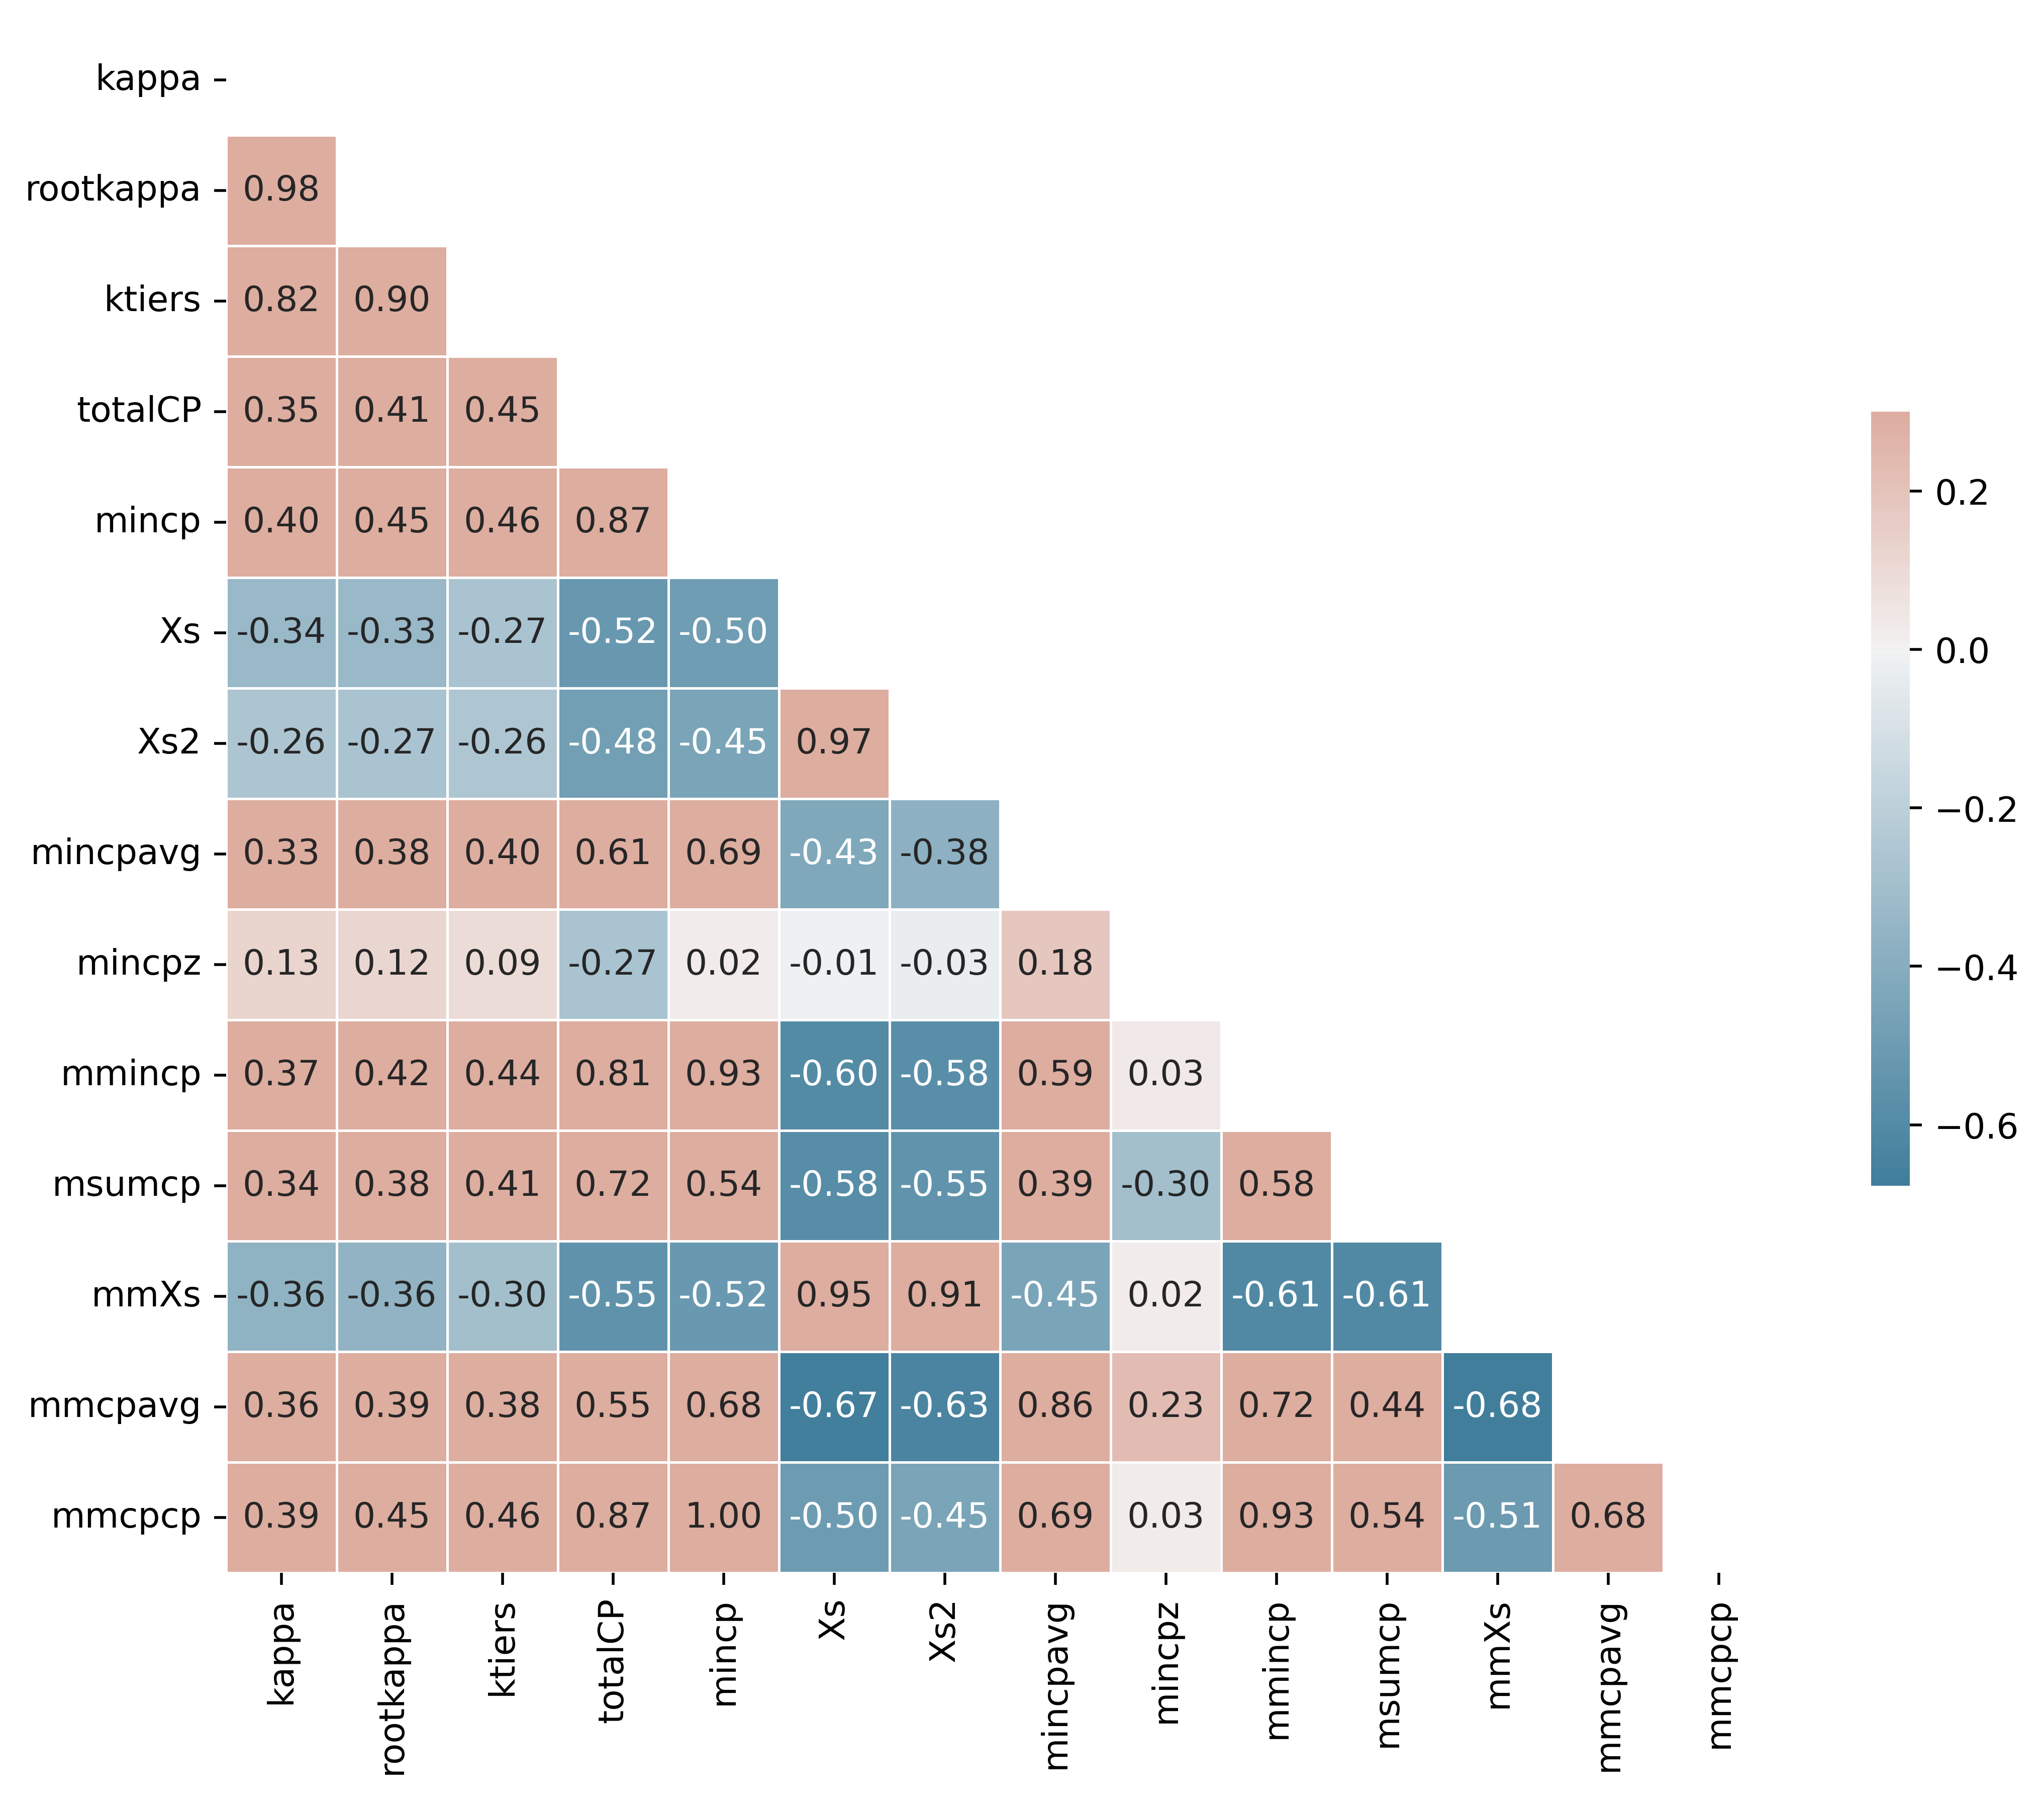

In [26]:
lowestCPnumbers=lowestCP.drop(['formulas','reduced','atom','mmatom','kclass','kunder','site','mmsite'], axis=1)
corr = lowestCPnumbers.corr(method = 'pearson')
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
plt.figure(figsize=(10,8), dpi =500)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, annot=True, fmt=".2f", cbar_kws={"shrink": .5})
plt.savefig('IMAGES/Correlation ESTM.png', bbox_inches='tight', dpi=1200)
plt.show()

In [27]:
lowestCP

,kappa,rootkappa,ktiers,kclass,kunder,formulas,reduced,totalCP,mincp,site,atom,Xs,Xs2,mincpavg,mincpz,mmincp,msumcp,mmsite,mmatom,mmXs,mmcpavg,mmcpcp
0,0.21,0.458258,0,under1,Under 1,Ag8SnSe6,Ag8SnSe6,-60.14,-311.019805,8,Ag,0.613036,0.375813,-2.283655,-1.630934,-190.666290,-1494.929625,8,Ag,0.613036,-1.399962,-311.019805
1,0.49,0.700000,0,under1,Under 1,Cu12Sb4S13,Cu12Sb4S13,23.77,-53.892510,27,Sb,0.052019,0.002706,-0.806798,-1.650172,-2.803436,1280.074020,27,Sb,0.052019,-0.041969,-53.892510
2,1.07,1.034408,1,undermedian,Over 1,MgAgSb,MgAgSb,-22.44,-255.500118,18,Ag,0.752533,0.566305,-4.517436,-2.920827,-192.272179,-972.998082,18,Ag,0.752533,-3.399518,-255.500118
3,1.40,1.183216,1,undermedian,Over 1,SnSe,SnSe,-25.02,-75.172031,7,Se,0.281924,0.079481,-1.876387,-1.418698,-21.192830,-66.768615,7,Se,0.281924,-0.528999,-75.172031
4,2.37,1.539480,2,under3,Over 1,TiS2,TiS2,-64.72,-230.044255,1,S,0.386127,0.149094,-1.295878,-0.707115,-88.826407,-112.801945,1,S,0.386127,-0.500374,-230.044255
5,6.75,2.598076,3,over3,Over 1,VFeSb,VFeSb,-25.26,-135.437310,11,Sb,0.391368,0.153169,-1.229776,-0.805786,-53.005797,-51.409492,11,Sb,0.391368,-0.481295,-135.437310
6,7.59,2.754995,3,over3,Over 1,LiCoO2,LiCoO2,61.17,75.963469,0,Li,0.973981,0.948639,0.619183,-1.199140,73.986975,1349.808131,0,Li,0.973981,0.603072,75.963469
7,8.04,2.835489,3,over3,Over 1,GeTe,GeTe,-2.31,-9.071446,3,Te,0.022768,0.000518,-2.391149,-1.536088,-0.206540,1.813129,3,Te,0.022768,-0.054442,-9.071446
8,8.30,2.880972,3,over3,Over 1,CoGeTe,CoGeTe,-6.99,-79.487578,22,Te,0.175537,0.030813,-1.084559,-0.854676,-13.953027,182.965172,22,Te,0.175537,-0.190380,-79.487578
9,8.43,2.903446,3,over3,Over 1,CuFeS2,FeCuS2,81.31,143.232877,13,S,0.421802,0.177917,0.880735,-1.030112,58.475700,1617.544571,15,S,0.406631,0.359565,143.805197


invalid escape sequence '\m'
invalid escape sequence '\m'
invalid escape sequence '\m'


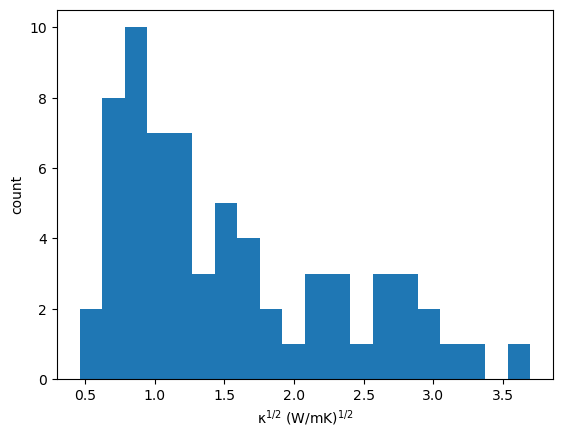

In [28]:
plt.hist(lowestCP['rootkappa'],bins=20)
plt.ylabel("count")
plt.xlabel('$\mathregular{\kappa^{1/2}}$ $\mathregular{(W/mK)^{1/2}}$')
plt.savefig('IMAGES/Thermal Conductivity Distribution (ESTM data).png', bbox_inches='tight', dpi=1200)

In [29]:
CPcolumns=[['mincp','mincpavg','totalCP'],['mmincp','mmcpavg','mmXs'],['mmcpcp','msumcp','Xs']]
CPcolumnsunits=[['$\mathregular{CP_{min}}$ (GPa)',' $\mathregular{CP_{min}/|CP|_{avg}}$','total CP (GPa)'],['$\mathregular{(CP*\chi_s)_{min}}$ (GPa)','$\mathregular{(CP*\chi_s)_{min}/|CP|_{avg}}$','$\mathregular{\chi_s}$ of $\mathregular{(CP*\chi_s)_{min}}$ site'],['CP of $\mathregular{(CP*\chi_s)_{min}}$ site (GPa)','$\mathregular{\sum(CP*\chi_s)}$ (GPa)','$\mathregular{\chi_s}$ of $\mathregular{CP_{min}}$ site']]


invalid escape sequence '\m'
invalid escape sequence '\m'
invalid escape sequence '\m'
invalid escape sequence '\m'
invalid escape sequence '\m'
invalid escape sequence '\m'
invalid escape sequence '\m'
invalid escape sequence '\m'
invalid escape sequence '\m'
invalid escape sequence '\m'
invalid escape sequence '\m'
invalid escape sequence '\m'
invalid escape sequence '\m'
invalid escape sequence '\m'
invalid escape sequence '\m'
invalid escape sequence '\m'
invalid escape sequence '\m'
invalid escape sequence '\m'
invalid escape sequence '\m'
invalid escape sequence '\m'
invalid escape sequence '\m'
invalid escape sequence '\m'
invalid escape sequence '\m'
invalid escape sequence '\m'


invalid escape sequence '\m'
invalid escape sequence '\m'
invalid escape sequence '\m'


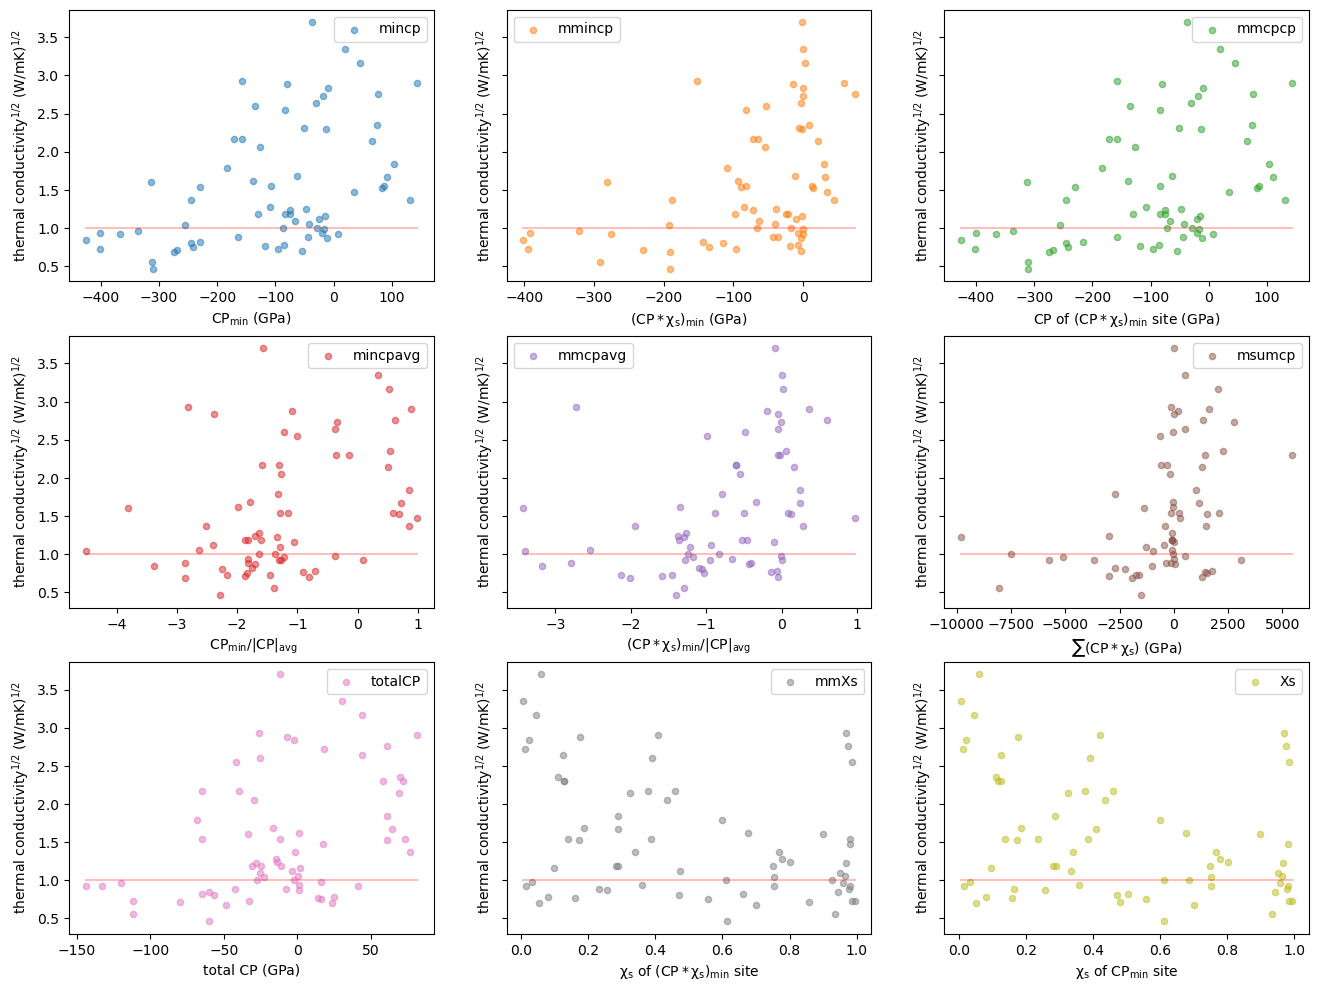

In [30]:
fig, axs = plt.subplots(3, 3,sharey=True, figsize=(16, 12))
colornumb=0
for i in range(3):
    for j in range(3):
        axs[i, j].scatter(lowestCP[CPcolumns[j][i]], lowestCP['rootkappa'],s=20,label=CPcolumns[j][i],c='C'+str(colornumb),alpha=0.5)
        axs[i, j].plot([min(lowestCP[CPcolumns[j][i]]),max(lowestCP[CPcolumns[j][i]])],[1,1],c='r',alpha=0.25)
        axs[i, j].set_xlabel(CPcolumnsunits[j][i])
        axs[i, j].legend()
        axs[i, j].set_ylabel('thermal $\mathregular{conductivity^{1/2}}$ $\mathregular{(W/mK)^{1/2}}$')
        colornumb+=1
plt.savefig('IMAGES/ESTM10Var.png', bbox_inches='tight', dpi=1500)

In [35]:
lowestCP.columns

Index(['kappa', 'rootkappa', 'ktiers', 'kclass', 'kunder', 'formulas',
       'reduced', 'totalCP', 'mincp', 'site', 'atom', 'Xs', 'Xs2', 'mincpavg',
       'mincpz', 'mmincp', 'msumcp', 'mmsite', 'mmatom', 'mmXs', 'mmcpavg',
       'mmcpcp'],
      dtype='object')

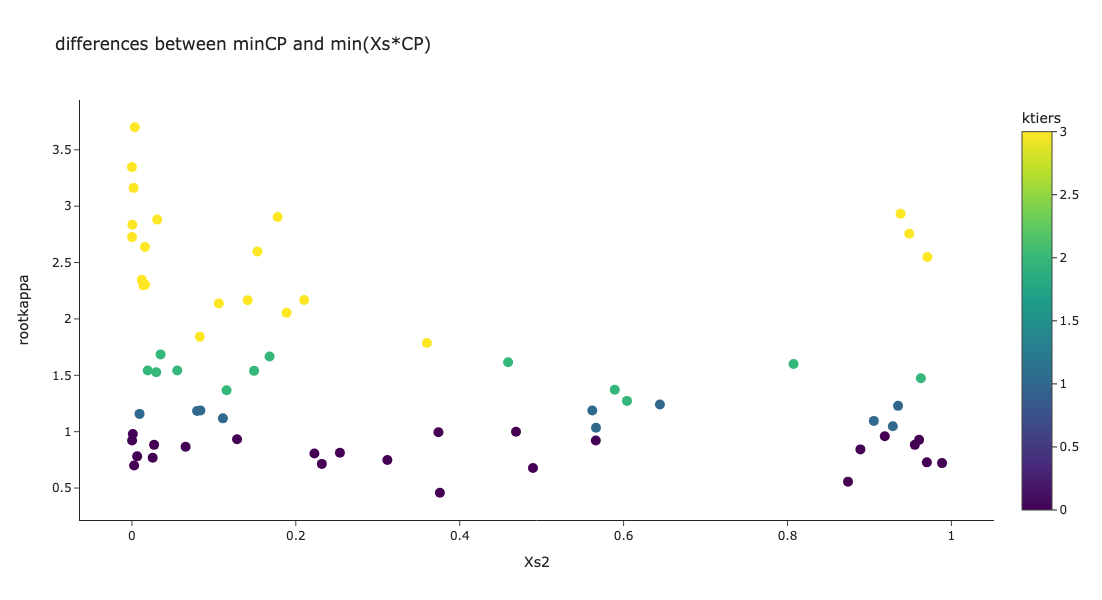

In [31]:
#any variables from the dataset can be placed here 
fig = px.scatter(lowestCP, y="rootkappa", x="Xs2", color="ktiers",title="differences between minCP and min(Xs*CP)",
                width=1000, height=600,hover_data=['formulas','atom','site','Xs','mmXs','mmatom'])
fig.update_traces(marker_size=10)
fig.show()


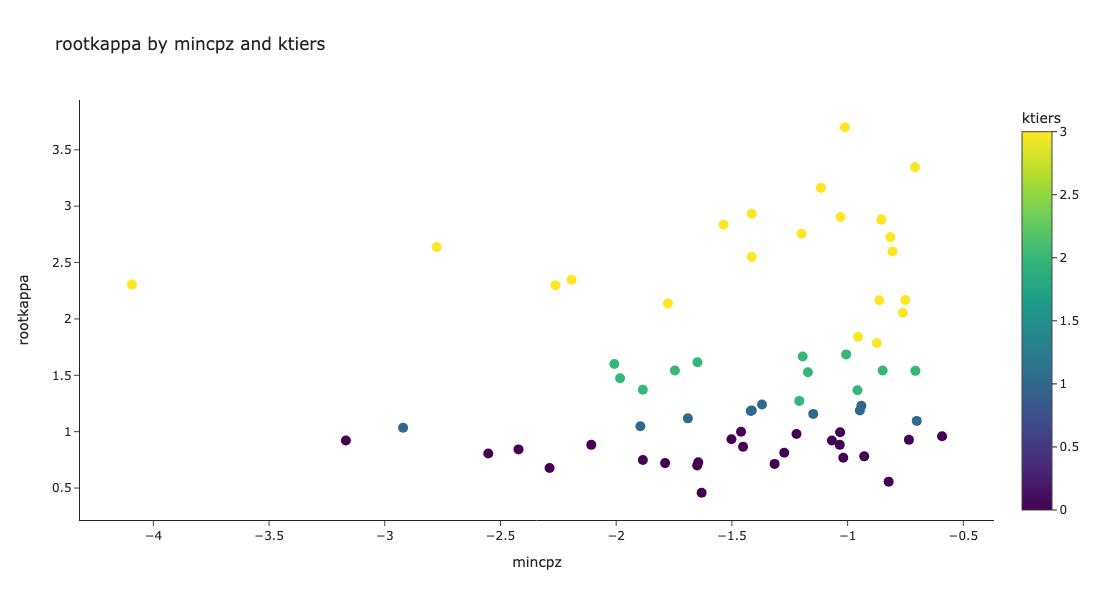

-21.29118457701637

In [33]:
xvalues="mincpz"
yvalues="rootkappa"
colorvalues="ktiers"
fig = px.scatter(lowestCP, y=yvalues, x=xvalues, color=colorvalues,title=f"{yvalues} by {xvalues} and {colorvalues}",
                width=1000, height=600,hover_data=['kappa','formulas','atom','site','Xs'])
fig.update_traces(marker_size=10)
fig.show()
r2_score(lowestCP[xvalues],lowestCP[yvalues])

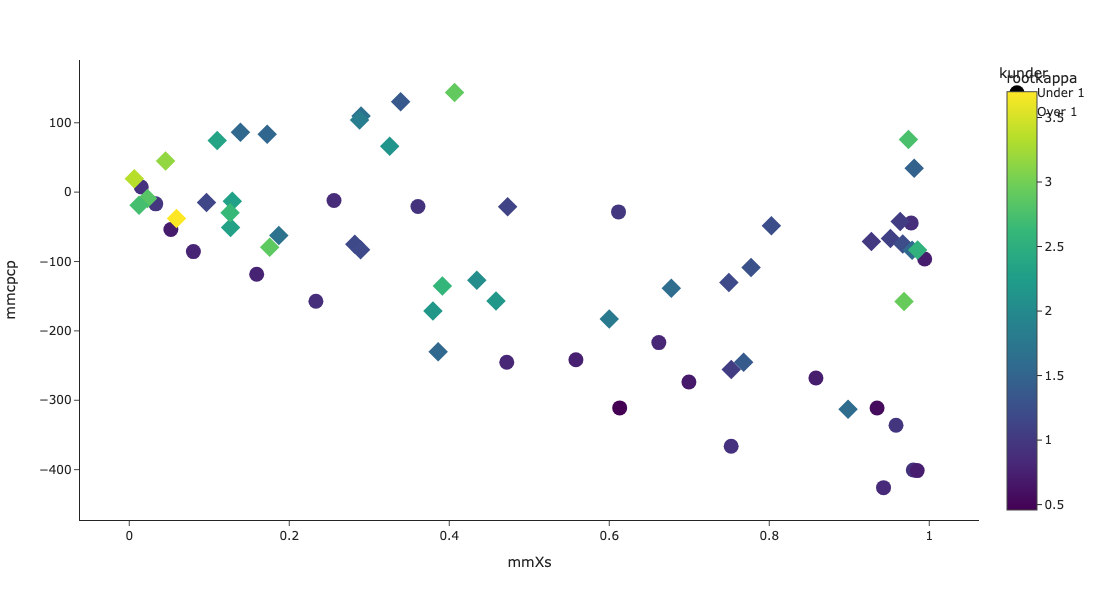

In [40]:
fig = px.scatter(lowestCP, y="mmcpcp", x="mmXs", color="rootkappa",symbol='kunder',
                width=1000, height=600)
fig.update_traces(marker_size=15)

fig.write_image("IMAGES/ESTMMMCPCPMMXS.png")
fig.show()

VARIABLES CREATED FOR EACH ATOM

In [42]:
allformula=[]
allCP=[]
allisCPmin=[]
allsite=[]
allatom=[]
allXs=[]
alltherm=[]


for i in range(len(formulas)):
    struct=mlcpdata[forms[i]]
    minimumindex=struct['CP'].index(min(struct['CP']))
    for n in range(len(struct['sites'])):
        allformula.append(struct['name'])
        allCP.append(struct['CP'][n])
        if n==minimumindex:
            allisCPmin.append(1)
        else:
            allisCPmin.append(0)
        allsite.append(n)
        allatom.append(struct['sites'][n])
        qps=[0,0,0,0,0]
        for j in range(5):
            for k in range(j**2,(j+1)**2): #an increasing odd number for each, as in the harmonics
                qps[j] += struct['coeffs'][n][k]**2 #combining each level squared, for l=0 to 4 for each atom
        try:
            allXs.append(qps[0]/sum(qps))
        except:
            allXs.append(0)
        alltherm.append(database.iloc[i].loc['thermal_conductivity(W/mK)'])

In [43]:
allatoms = pd.DataFrame()

In [44]:
allatoms['formulas']=allformula
allatoms['cp']=allCP
allatoms['ismin']=allisCPmin
allatoms['site']=allsite
allatoms['atom']=allatom
allatoms['Xs']=allXs
allatoms['kappa']=alltherm
allatoms['Xs2']=allatoms['Xs']**2
allatoms['mult']=allatoms['Xs']*allatoms['cp']
allatoms['rootkappa']=allatoms['kappa']**0.5

In [45]:
allatoms.columns

Index(['formulas', 'cp', 'ismin', 'site', 'atom', 'Xs', 'kappa', 'Xs2', 'mult',
       'rootkappa'],
      dtype='object')

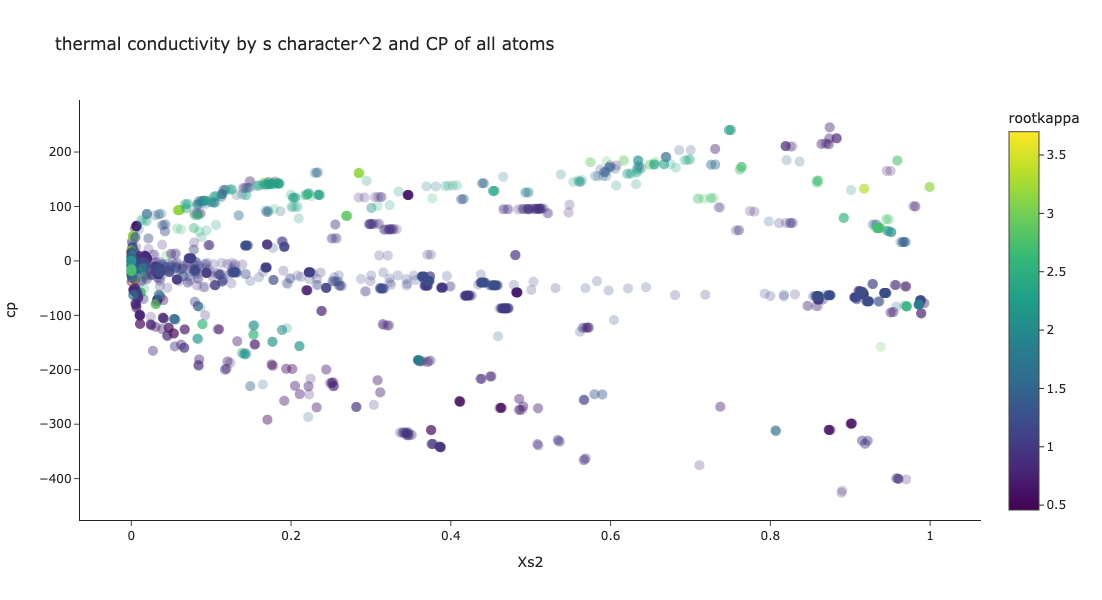

In [47]:
#similarly, the variables can go in here
fig = px.scatter(allatoms, y="cp", x="Xs2", color="rootkappa",title="thermal conductivity by s character^2 and CP of all atoms",
                width=1000, height=600,hover_data=['formulas','atom','site','Xs'],opacity=0.25)
fig.update_traces(marker_size=10)
fig.show()

In [48]:
#creating features for all compositions
ThermFeatures=ref3.write_features_ratio(database,label_col = 'Formula')

100%|██████████████████████████████████████████| 67/67 [00:00<00:00, 237.62it/s]

Data Shape: (67, 217)


In [49]:
ThermData=ThermFeatures.join(database.reset_index(drop=True))

ThermData=ThermData.drop(['Xs'], axis=1)
ThermData2=ThermData.join(lowestCP.reset_index(drop=True))

In [50]:
ThermData2['lowthermal']=[1 if a<1 else 0 for a in ThermData2['thermal_conductivity(W/mK)']]

In [51]:
therm_train,y_train,therm_test,y_test=ref3.split(ThermData2,ThermData2.loc[:,'lowthermal'],split_fraction=0.7)

Training data size: 47
Test data size: 20


In [52]:
#creating different datasets for each
Comp=np.r_[0:217]
CPandComp=np.r_[0:217,239:241,243:249,251:254]
CPonly=np.r_[239:241,243:249,251:254]

In [53]:
X_train=therm_train.iloc[:,Comp]
X_trainCP=therm_train.iloc[:,CPandComp]
X_test=therm_test.iloc[:,Comp]
X_testCP=therm_test.iloc[:,CPandComp]
X_trainCPonly=therm_train.iloc[:,CPonly]
X_testCPonly=therm_test.iloc[:,CPonly]

In [54]:
kpred={}
kpred['train']=X_train
kpred['trainCP']=X_trainCP
kpred['trainCPO']=X_trainCPonly
kpred['test']=X_test
kpred['testCP']=X_testCP
kpred['testCPO']=X_testCPonly
kpred['ytrain']=y_train
kpred['ytest']=y_test

In [55]:
#creating the models
for j in ['','CP','CPO']:
    kpred['rfcmodel'+j]=RandomForestClassifier(max_features=0.6).fit(kpred['train'+j],kpred['ytrain'])
    kpred['dtcmodel'+j]=DecisionTreeClassifier().fit(kpred['train'+j],kpred['ytrain'])
    kpred['hgbcmodel'+j]=HistGradientBoostingClassifier().fit(kpred['train'+j],kpred['ytrain'])
    kpred['gbcmodel'+j]=GradientBoostingClassifier(max_features=0.6).fit(kpred['train'+j],kpred['ytrain'])

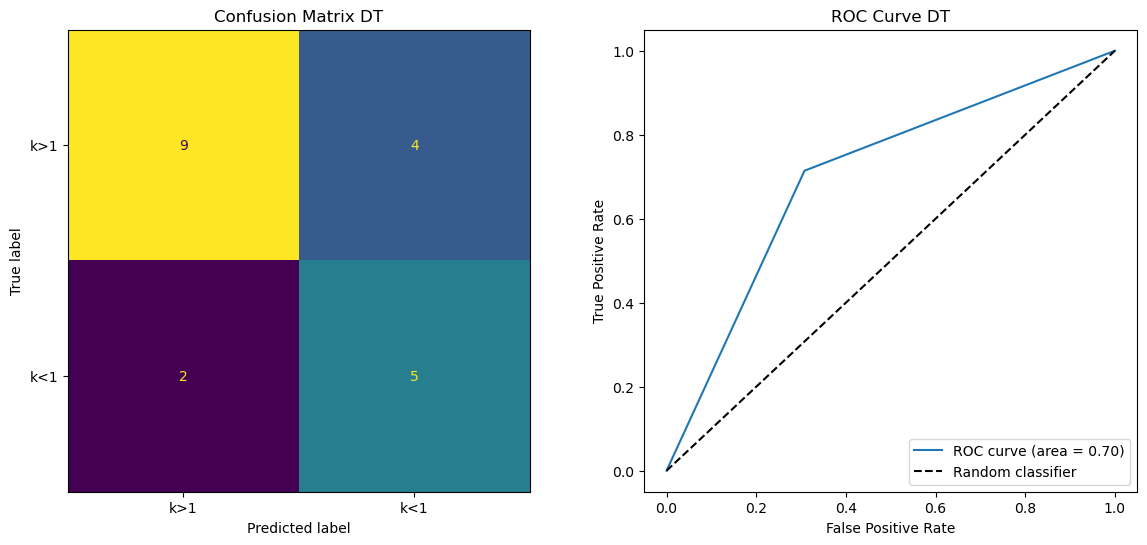

Accuracy:  0.7
Precision:  0.556
Recall:  0.714


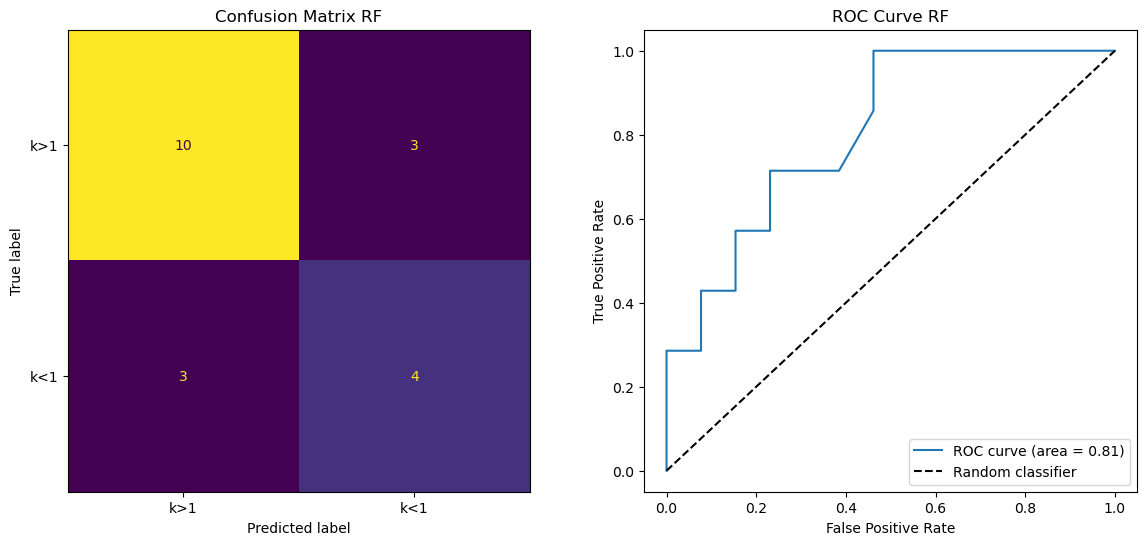

Accuracy:  0.7
Precision:  0.571
Recall:  0.571


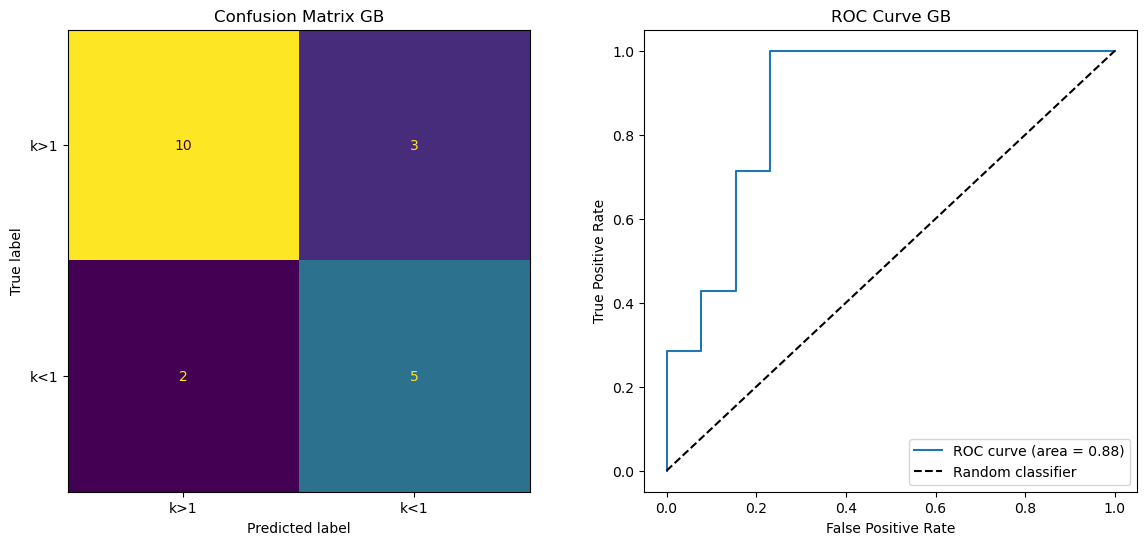

Accuracy:  0.75
Precision:  0.625
Recall:  0.714


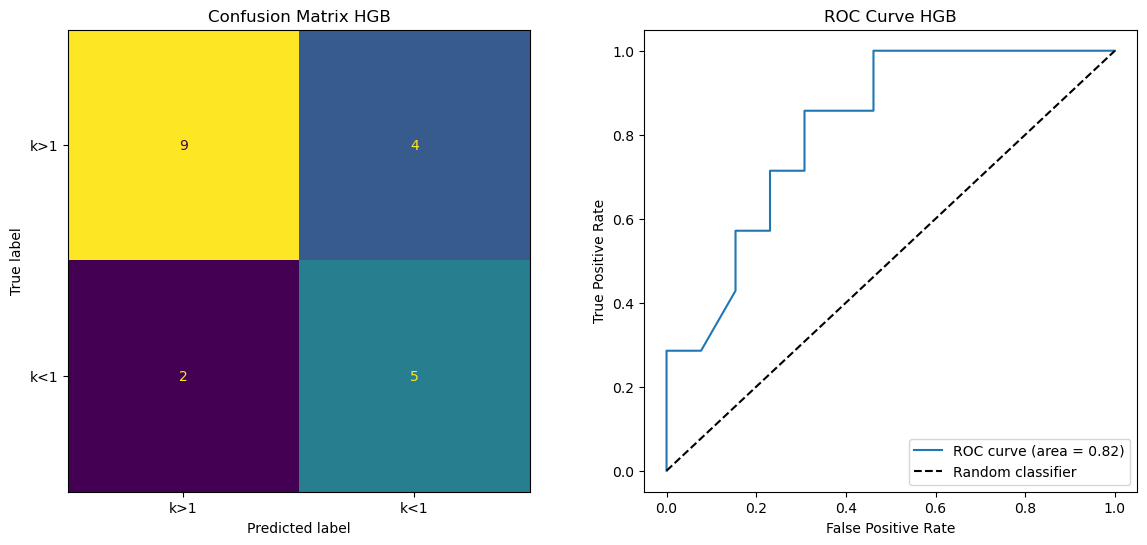

Accuracy:  0.7
Precision:  0.556
Recall:  0.714


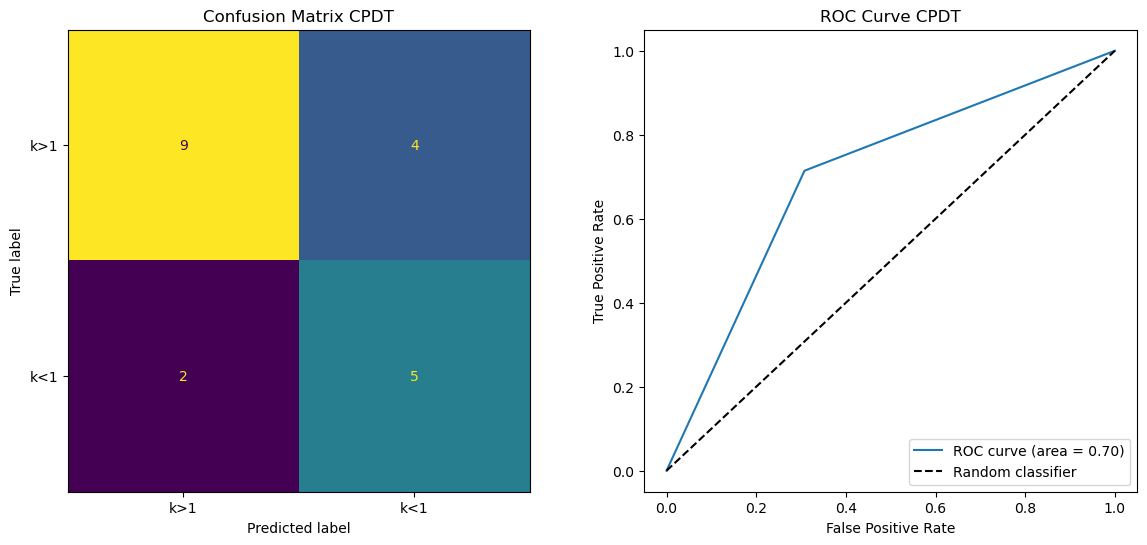

Accuracy:  0.7
Precision:  0.556
Recall:  0.714


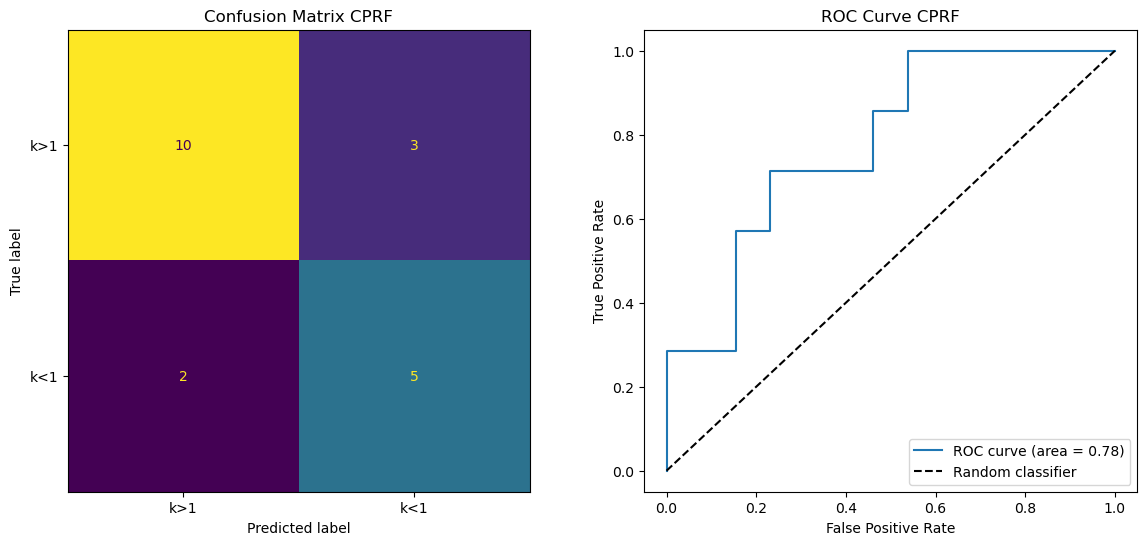

Accuracy:  0.75
Precision:  0.625
Recall:  0.714


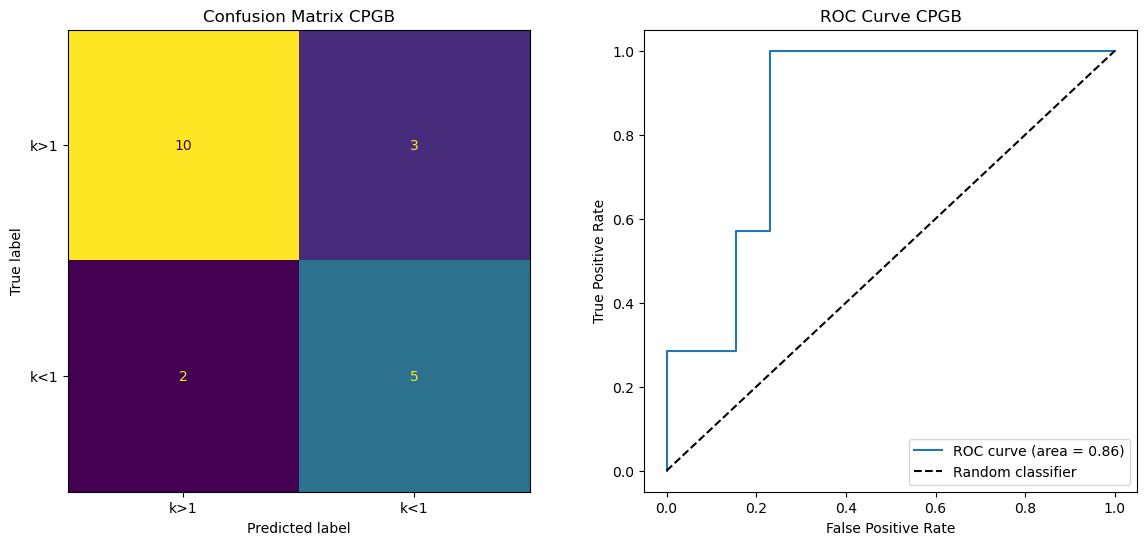

Accuracy:  0.75
Precision:  0.625
Recall:  0.714


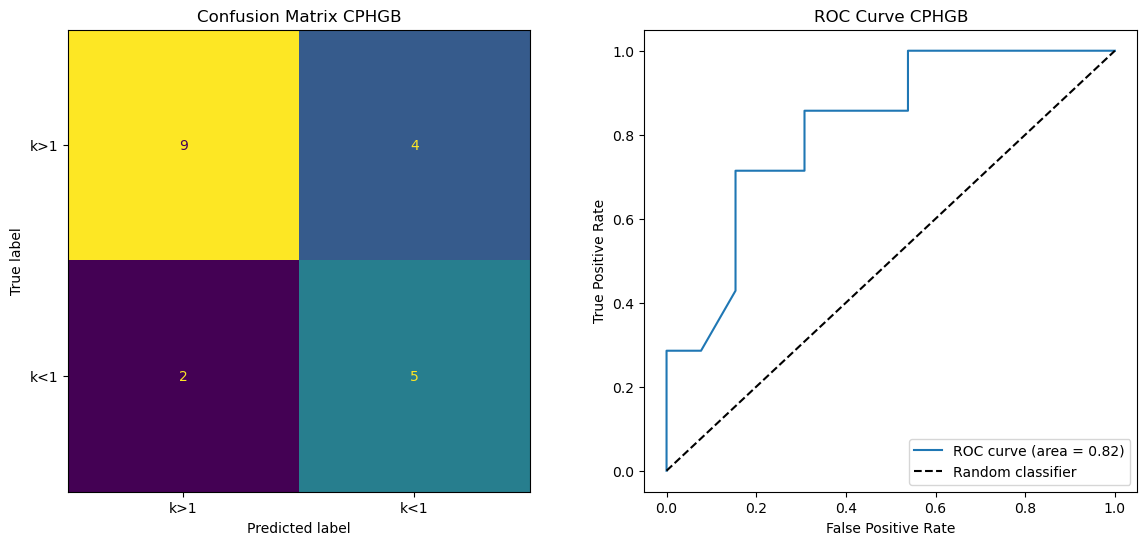

Accuracy:  0.7
Precision:  0.556
Recall:  0.714


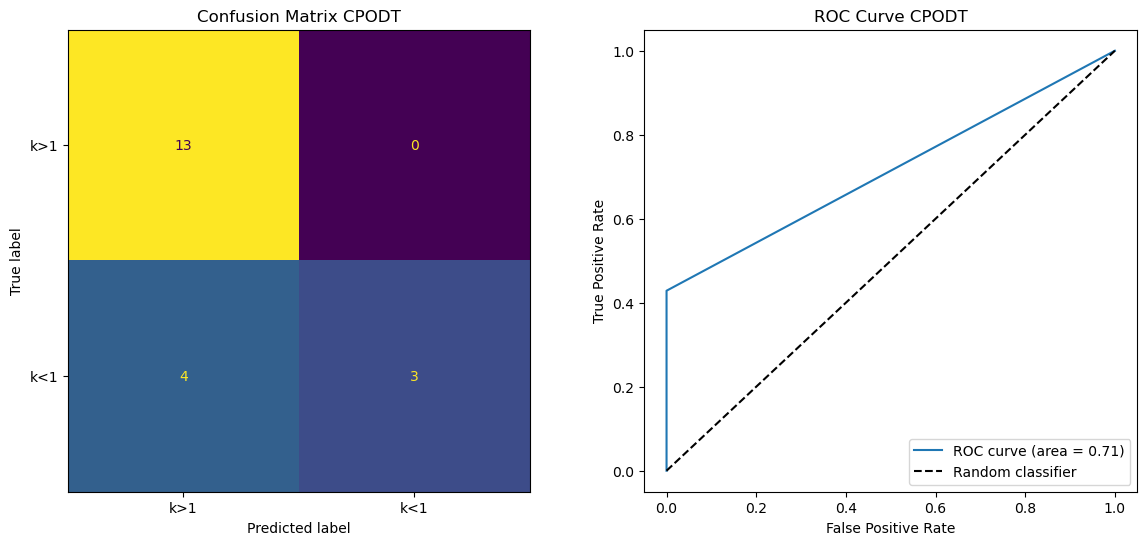

Accuracy:  0.8
Precision:  1.0
Recall:  0.429


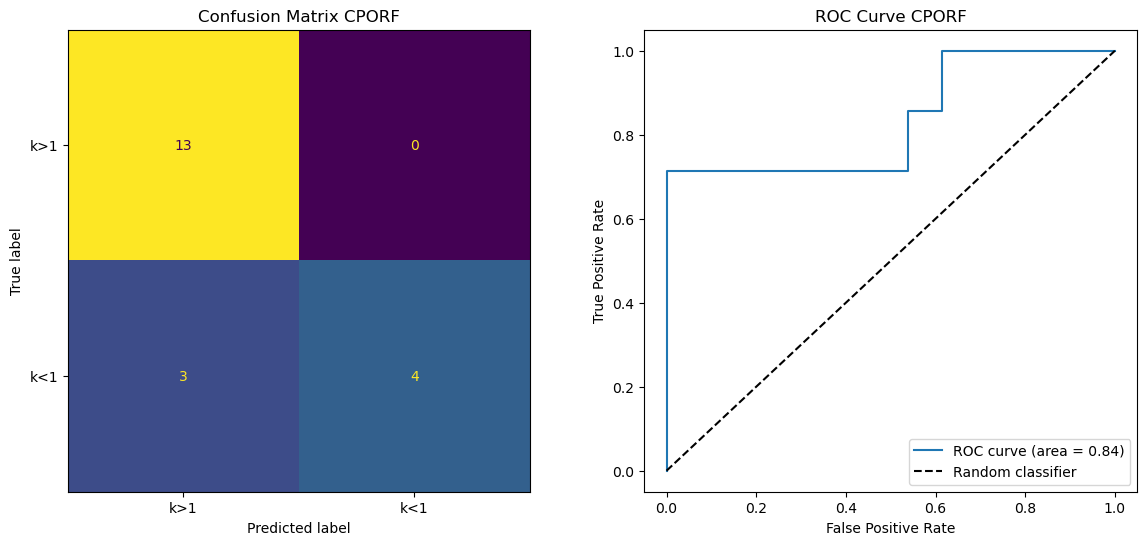

Accuracy:  0.85
Precision:  1.0
Recall:  0.571


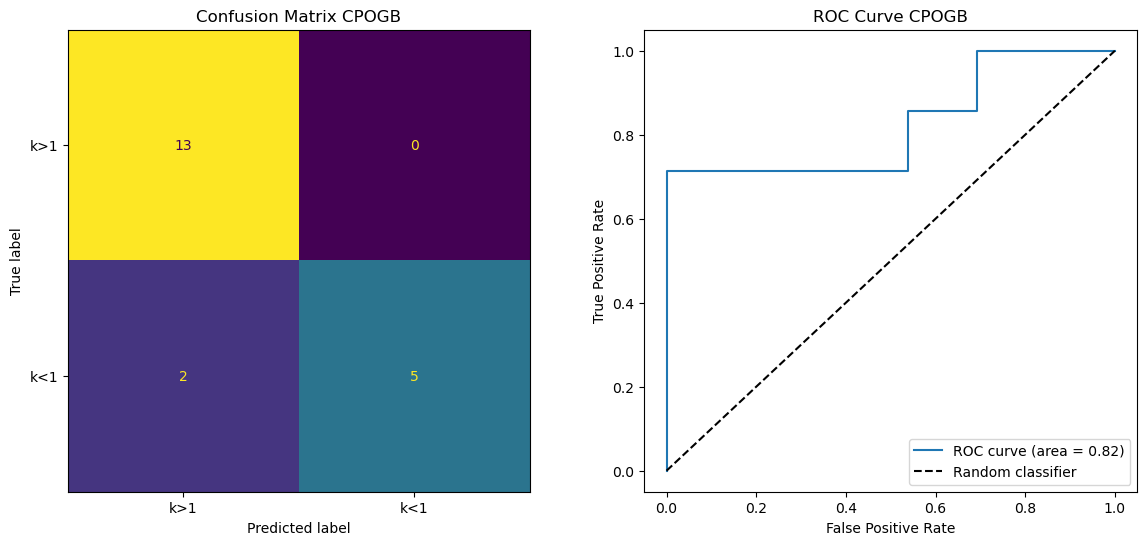

Accuracy:  0.9
Precision:  1.0
Recall:  0.714


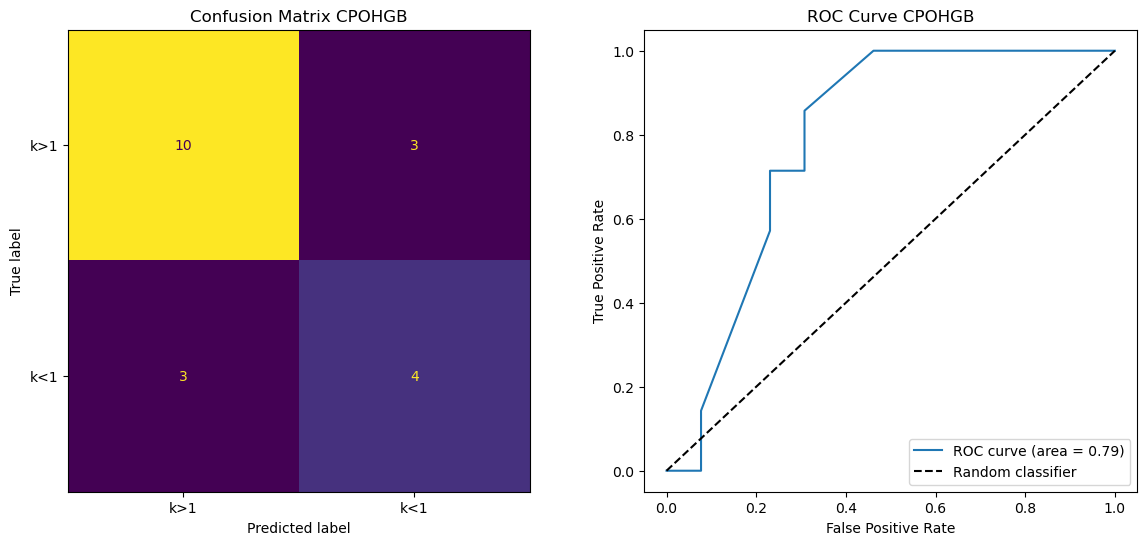

Accuracy:  0.7
Precision:  0.571
Recall:  0.571


In [57]:
#testing the models
threshold=1
for j in ['','CP','CPO']:
    gorup=j
    ref3.rocconfusion(kpred['dtcmodel'+j],kpred['test'+j],kpred['ytest'],[f"k>{threshold}", f"k<{threshold}"],title=gorup+'DT')
    ref3.rocconfusion(kpred['rfcmodel'+j],kpred['test'+j],kpred['ytest'],[f"k>{threshold}", f"k<{threshold}"],title=gorup+'RF')
    ref3.rocconfusion(kpred['gbcmodel'+j],kpred['test'+j],kpred['ytest'],[f"k>{threshold}", f"k<{threshold}"],title=gorup+'GB')
    ref3.rocconfusion(kpred['hgbcmodel'+j],kpred['test'+j],kpred['ytest'],[f"k>{threshold}", f"k<{threshold}"],title=gorup+'HGB')

In [81]:
#regression
k_train,ky_train,k_test,ky_test=ref3.split(ThermData2,ThermData2.loc[:,'thermal_conductivity(W/mK)'],split_fraction=0.7)

Training data size: 47
Test data size: 20


In [82]:
#seeing how similar the groups are
print(np.mean(ky_train))
print(np.mean(ky_test))


3.3140425531914888
2.3015


In [83]:
kX_train=k_train.iloc[:,Comp]
kX_trainCP=k_train.iloc[:,CPandComp]
kX_test=k_test.iloc[:,Comp]
kX_testCP=k_test.iloc[:,CPandComp]
kX_trainCPonly=k_train.iloc[:,CPonly]
kX_testCPonly=k_test.iloc[:,CPonly]

In [84]:
kpred={}
kpred['rtrain']=kX_train
kpred['rtrainCP']=kX_trainCP
kpred['rtrainCPO']=kX_trainCPonly
kpred['rtest']=kX_test
kpred['rtestCP']=kX_testCP
kpred['rtestCPO']=kX_testCPonly
kpred['rytrain']=ky_train
kpred['rytest']=ky_test

In [87]:
for j in ['','CP','CPO']:
    kpred['Rrfrmodel'+j]=RandomForestRegressor(max_features=0.6).fit(kpred['rtrain'+j],kpred['rytrain'])
    kpred['Rgbrmodel'+j]=GradientBoostingRegressor(max_features=0.6).fit(kpred['rtrain'+j],kpred['rytrain'])

Cross validation r2_score 0.4911
Cross validation mean_absolute_error 1.8426
Cross validation mean_squared_error 5.3303


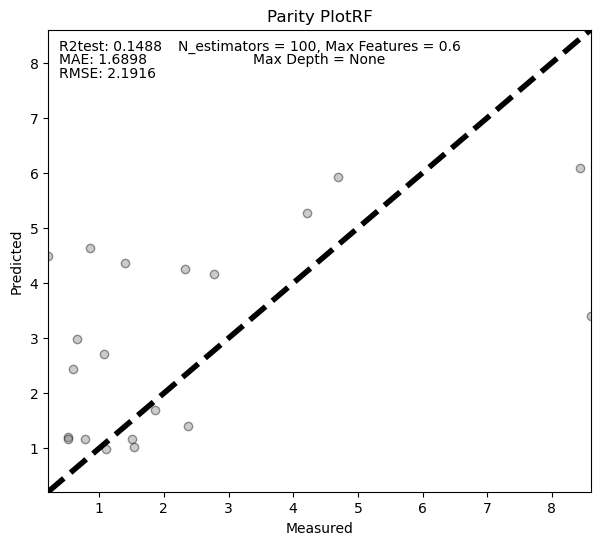

Cross validation r2_score 0.5058
Cross validation mean_absolute_error 1.6759
Cross validation mean_squared_error 5.1767


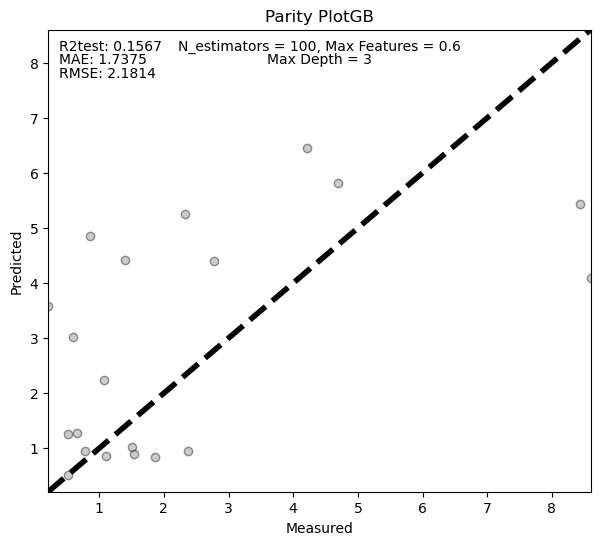

Cross validation r2_score 0.4951
Cross validation mean_absolute_error 1.878
Cross validation mean_squared_error 5.2887


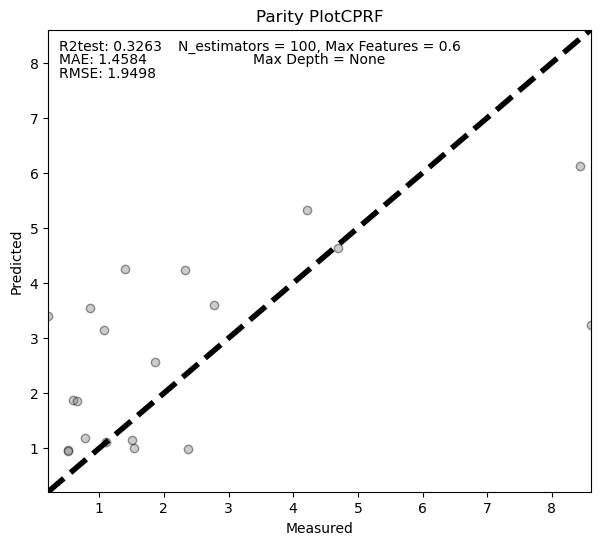

Cross validation r2_score 0.4382
Cross validation mean_absolute_error 1.8244
Cross validation mean_squared_error 5.8847


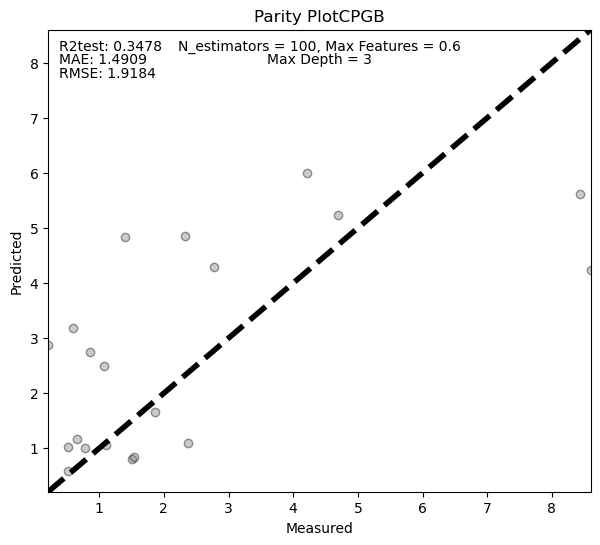

Cross validation r2_score -0.0239
Cross validation mean_absolute_error 2.441
Cross validation mean_squared_error 10.7248


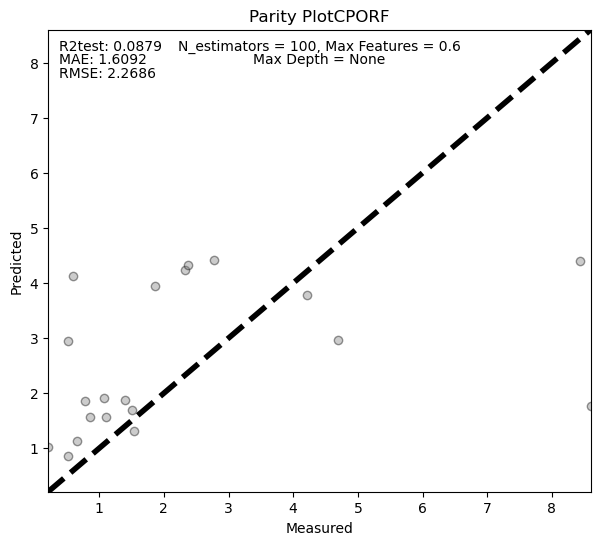

Cross validation r2_score -0.2076
Cross validation mean_absolute_error 2.5439
Cross validation mean_squared_error 12.6481


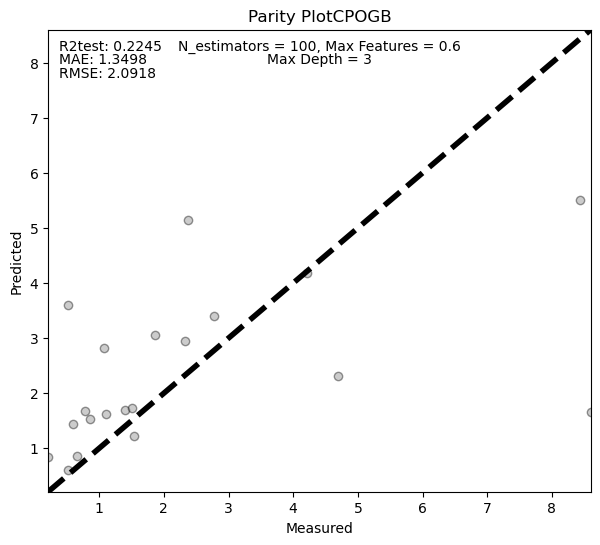

In [89]:
for j in ['','CP','CPO']:
    gorup=j
    ref3.test_rf_model(kpred['rtrain'+j],kpred['rytrain'],kpred['rtest'+j],kpred['rytest'],kpred['Rrfrmodel'+j],title=j+'RF')
    ref3.test_rf_model(kpred['rtrain'+j],kpred['rytrain'],kpred['rtest'+j],kpred['rytest'],kpred['Rgbrmodel'+j],title=j+'GB')